# Part B: Naive Bayes Classifier Implementation


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.naive_bayes import MultinomialNB
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

### DATA PROCESSING
**Loading the DATASET**

In [2]:
df = pd.read_csv(r"C:\Users\me\Desktop\Engineering_Term _7\Machine_Learning\8858_assignment\adult.csv")

**Selecting categorial features**

In [3]:
categorical_features = ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex']
target = 'income'
df = df[categorical_features + [target]]

**Handling missing values by treating them as a separate category**

In [4]:
df = df.fillna('?')
df = df.replace('?', 'Missing')
print(df.head())

  workclass     education marital.status         occupation   relationship  \
0   Missing       HS-grad        Widowed            Missing  Not-in-family   
1   Private       HS-grad        Widowed    Exec-managerial  Not-in-family   
2   Missing  Some-college        Widowed            Missing      Unmarried   
3   Private       7th-8th       Divorced  Machine-op-inspct      Unmarried   
4   Private  Some-college      Separated     Prof-specialty      Own-child   

    race     sex income  
0  White  Female  <=50K  
1  White  Female  <=50K  
2  Black  Female  <=50K  
3  White  Female  <=50K  
4  White  Female  <=50K  


**Encoding categories as integers**

Class distribution in the dataset:
income
0    24720
1     7841
Name: count, dtype: int64


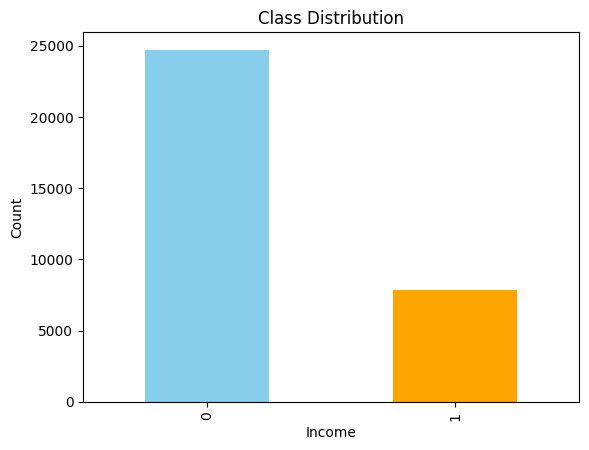


Feature: workclass
income         0     1
workclass             
0           1645   191
1          17733  4963
2            945   353
3            589   371
4           1817   724
5            494   622
6           1476   617
7             14     0
8              7     0


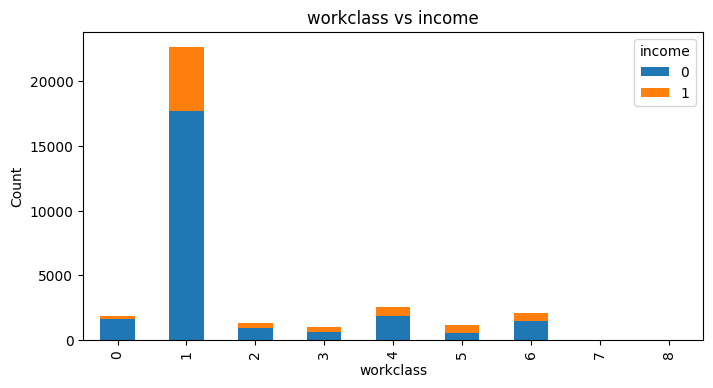


Feature: education
income        0     1
education            
0          8826  1675
1          5904  1387
2           606    40
3           871    62
4           107   306
5           153   423
6          3134  2221
7           764   959
8          1115    60
9           802   265
10         1021   361
11          162     6
12          317    16
13          400    33
14          487    27
15           51     0


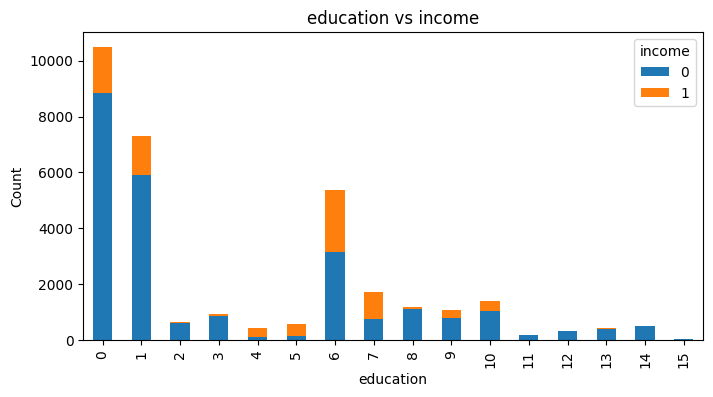


Feature: marital.status
income              0     1
marital.status             
0                 908    85
1                3980   463
2                 959    66
3               10192   491
4                8284  6692
5                 384    34
6                  13    10


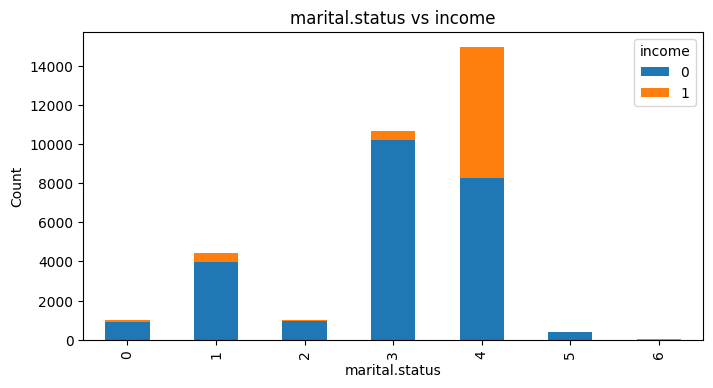


Feature: occupation
income         0     1
occupation            
0           1652   191
1           2098  1968
2           1752   250
3           2281  1859
4           3158   137
5           3263   507
6           3170   929
7           1277   320
8           1284    86
9           2667   983
10           879   115
11           645   283
12           438   211
13             8     1
14           148     1


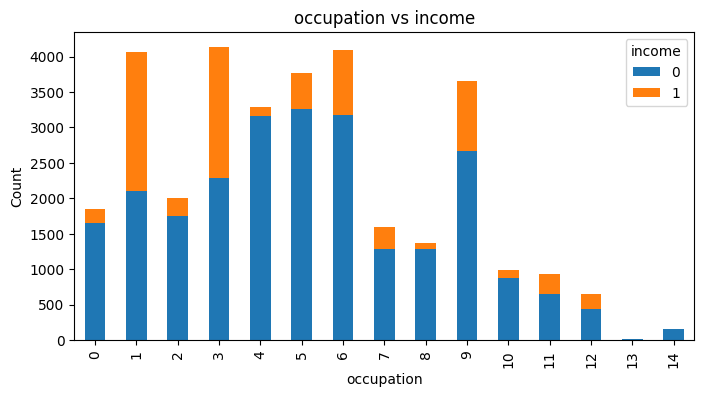


Feature: relationship
income           0     1
relationship            
0             7449   856
1             3228   218
2             5001    67
3              944    37
4             7275  5918
5              823   745


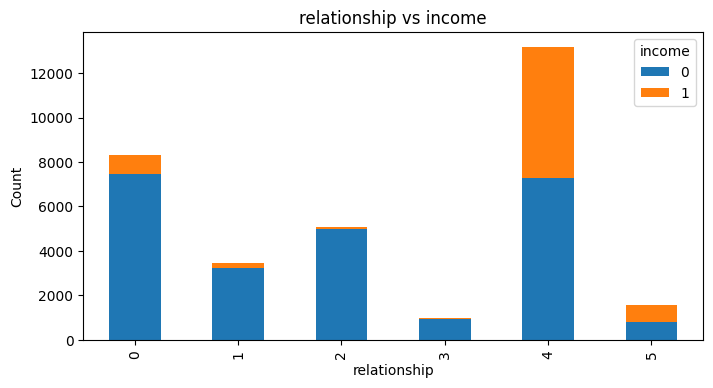


Feature: race
income      0     1
race               
0       20699  7117
1        2737   387
2         763   276
3         246    25
4         275    36


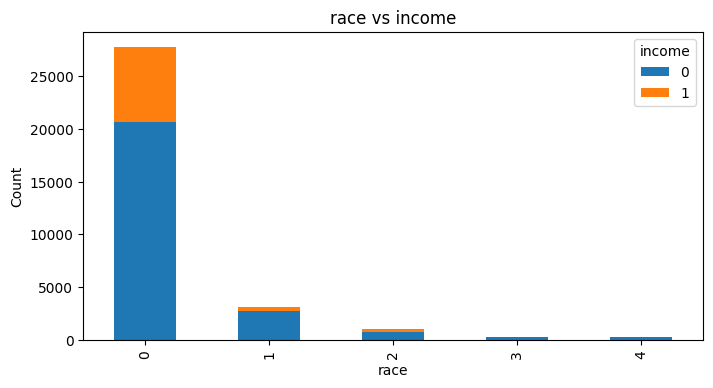


Feature: sex
income      0     1
sex                
0        9592  1179
1       15128  6662


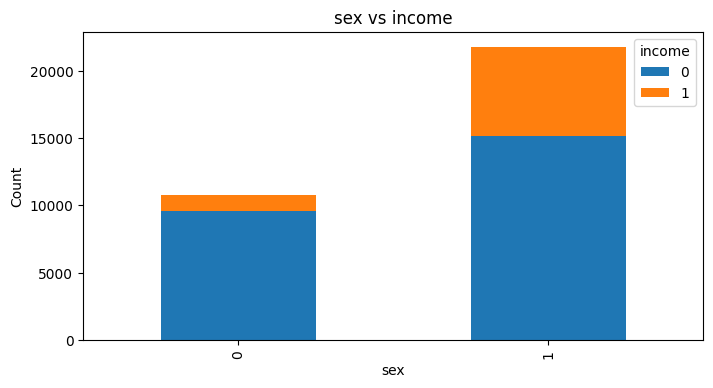

   workclass  education  marital.status  occupation  relationship  race  sex  \
0          0          0               0           0             0     0    0   
1          1          0               0           1             0     0    0   
2          0          1               0           0             1     1    0   
3          1          2               1           2             1     0    0   
4          1          1               2           3             2     0    0   

   income  
0       0  
1       0  
2       0  
3       0  
4       0  


In [5]:
feature_maps = {}
for col in categorical_features + [target]:
    df[col], feature_maps[col] = pd.factorize(df[col])
# 1. Class distribution
print("Class distribution in the dataset:")
print(df[target].value_counts())
df[target].value_counts().plot(kind='bar', color=['skyblue','orange'])
plt.title("Class Distribution")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()
# 2. Feature-target relationships
for col in categorical_features:
    print(f"\nFeature: {col}")
    crosstab = pd.crosstab(df[col], df[target])
    print(crosstab)
    crosstab.plot(kind='bar', stacked=True, figsize=(8,4))
    plt.title(f"{col} vs {target}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()
X = df[categorical_features].values
y = df[target].values
print(df.head())

**Train/Validation/Test Split**

In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=222, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=222, stratify=y_temp)

### **Naïve Bayes Implementation**
- alpha is the smoothing parameter
- it calculates class priors P(C_k)
- it calculates feature likelihoods P(x_i|C_k)
- Prediction: argmax_k P(C_k) * P(x_i|C_k) (for each)

In [7]:
class NaiveBayesClassifier:
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.class_priors = None
        self.feature_likelihoods = {}
        self.num_classes = None
        self.feature_value_counts = {}
        
    def fit(self, X, y):
        self.num_classes = len(np.unique(y))
        n_features = X.shape[1]
        self.class_priors = {}
        for c in range(self.num_classes):
            self.class_priors[c] = (np.sum(y == c) + self.alpha) / (len(y) + self.alpha * self.num_classes)
        for f in range(n_features):
            self.feature_likelihoods[f] = {}
            self.feature_value_counts[f] = len(np.unique(X[:, f]))
            for c in range(self.num_classes):
                counts = {}
                feature_values_in_class = X[y == c, f]
                for val in np.unique(X[:, f]):
                    counts[val] = (np.sum(feature_values_in_class == val) + self.alpha) / \
                                  (len(feature_values_in_class) + self.alpha * self.feature_value_counts[f])
                self.feature_likelihoods[f][c] = counts
                
    def predict(self, X):
        y_pred = []
        for x in X:
            class_probs = {}
            for c in range(self.num_classes):
                prob = self.class_priors[c]
                for f in range(len(x)):
                    prob *= self.feature_likelihoods[f][c].get(x[f], 1e-6)
                class_probs[c] = prob
            y_pred.append(max(class_probs, key=class_probs.get))
        return np.array(y_pred)

**Train & Evaluate**

In [8]:
nb = NaiveBayesClassifier(alpha=0)
nb.fit(X_train, y_train)
y_pred_val = nb.predict(X_val)
y_pred_test = nb.predict(X_test)
accuracy_val = np.mean(y_pred_val == y_val)
accuracy_test = np.mean(y_pred_test == y_test)
print("Validation Accuracy:", accuracy_val)
print("Test Accuracy:", accuracy_test)

Validation Accuracy: 0.7991400491400491
Test Accuracy: 0.7897645854657114


**Different alphas**

In [9]:
for alpha in [0.1, 0.5, 1.0, 2.0, 5.0]:
    nb = NaiveBayesClassifier(alpha=alpha)
    nb.fit(X_train, y_train)
    acc = np.mean(nb.predict(X_test) == y_test)
    print(f"Alpha: {alpha}, Testing Accuracy: {acc}")

Alpha: 0.1, Testing Accuracy: 0.7897645854657114
Alpha: 0.5, Testing Accuracy: 0.7897645854657114
Alpha: 1.0, Testing Accuracy: 0.7895598771750256
Alpha: 2.0, Testing Accuracy: 0.7893551688843398
Alpha: 5.0, Testing Accuracy: 0.7889457523029683


**Compare with sklearn’s MultinomialNB**

In [10]:
sk_nb = MultinomialNB(alpha=0)
sk_nb.fit(X_train, y_train)
sk_pred = sk_nb.predict(X_test)
nb = NaiveBayesClassifier(alpha=1)
nb.fit(X_train, y_train)
acc = np.mean(nb.predict(X_test) == y_test)
print("Sklearn MultinomialNB Test Accuracy:", accuracy_score(y_test, sk_pred), " VS Manual : " , acc)

Sklearn MultinomialNB Test Accuracy: 0.779324462640737  VS Manual :  0.7895598771750256


In [11]:
def evaluate_subset(cols):
    Xtr = X_train[:, cols]
    Xv  = X_val[:, cols]

    model = NaiveBayesClassifier(alpha=1.0)
    model.fit(Xtr, y_train)
    y_hat = model.predict(Xv)

    acc = accuracy_score(y_val, y_hat)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_val, y_hat, average='binary', pos_label = 1, zero_division=0
    )
    return acc, prec, rec, f1


# --- A) Single-feature ranking ---
print("Single-feature ranking:")
single_scores = []
for i, name in enumerate(categorical_features):
    acc, p, r, f = evaluate_subset([i])
    single_scores.append((i, name, acc, p, r, f))
    print(f"{name:18s} acc={acc:.4f} prec={p:.4f} rec={r:.4f} f1={f:.4f}")


# --- B) Top-k feature subsets ---
ranked = sorted(single_scores, key=lambda x: x[2], reverse=True)
top_indices = [i for (i, _, _, _, _, _) in ranked]

print("\nTop-k feature combinations:")
for k in [1, 2, 3, 4, 5, len(top_indices)]:
    subset = top_indices[:k]
    acc, p, r, f = evaluate_subset(subset)
    print(f"k={k:2d}: acc={acc:.4f} prec={p:.4f} rec={r:.4f} f1={f:.4f}")


# --- C) Full feature set ---
print("\nFull feature set:")
acc, p, r, f = evaluate_subset(list(range(len(categorical_features))))
print(f"acc={acc:.4f} prec={p:.4f} rec={r:.4f} f1={f:.4f}")


Single-feature ranking:
workclass          acc=0.7621 prec=0.5432 rec=0.0748 f1=0.1315
education          acc=0.7793 prec=0.6134 rec=0.2253 f1=0.3296
marital.status     acc=0.7592 prec=0.0000 rec=0.0000 f1=0.0000
occupation         acc=0.7592 prec=0.0000 rec=0.0000 f1=0.0000
relationship       acc=0.7592 prec=0.0000 rec=0.0000 f1=0.0000
race               acc=0.7592 prec=0.0000 rec=0.0000 f1=0.0000
sex                acc=0.7592 prec=0.0000 rec=0.0000 f1=0.0000

Top-k feature combinations:
k= 1: acc=0.7793 prec=0.6134 rec=0.2253 f1=0.3296
k= 2: acc=0.7815 prec=0.6088 rec=0.2594 f1=0.3637
k= 3: acc=0.8221 prec=0.6946 rec=0.4660 f1=0.5578
k= 4: acc=0.8290 prec=0.6778 rec=0.5527 f1=0.6089
k= 5: acc=0.8145 prec=0.6038 rec=0.6675 f1=0.6341
k= 7: acc=0.7991 prec=0.5653 rec=0.7177 f1=0.6324

Full feature set:
acc=0.7991 prec=0.5653 rec=0.7177 f1=0.6324


**Probability Analysis: Predicted Probability Distribution Analysis**

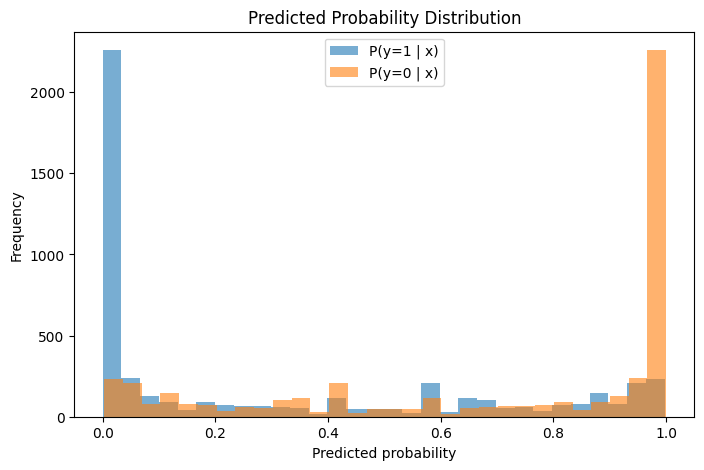

Positive class probability mean: 0.29473536904922965
Negative class probability mean: 0.7052646309507704


In [12]:
def predict_proba(model, X):
    probs = []
    for x in X:
        class_scores = {}
        for c in range(model.num_classes):
            score = np.log(model.class_priors[c])
            for f in range(len(x)):
                val = x[f]
                likelihood = model.feature_likelihoods[f][c].get(val, 1e-6)
                score += np.log(likelihood)
            class_scores[c] = score

        # softmax normalization
        vals = np.array(list(class_scores.values()))
        vals -= vals.max()
        exp_vals = np.exp(vals)
        probs.append(exp_vals / exp_vals.sum())
    return np.array(probs)
# Train on full features
model = NaiveBayesClassifier(alpha=1.0)
model.fit(X_train, y_train)
probs = predict_proba(model, X_val)
pos_probs = probs[:, 1]
neg_probs = probs[:, 0]
plt.figure(figsize=(8,5))
plt.hist(pos_probs, bins=30, alpha=0.6, label="P(y=1 | x)")
plt.hist(neg_probs, bins=30, alpha=0.6, label="P(y=0 | x)")
plt.xlabel("Predicted probability")
plt.ylabel("Frequency")
plt.title("Predicted Probability Distribution")
plt.legend()
plt.show()
print("Positive class probability mean:", pos_probs.mean())
print("Negative class probability mean:", neg_probs.mean())

**Independence Assumption Violation Analysis**

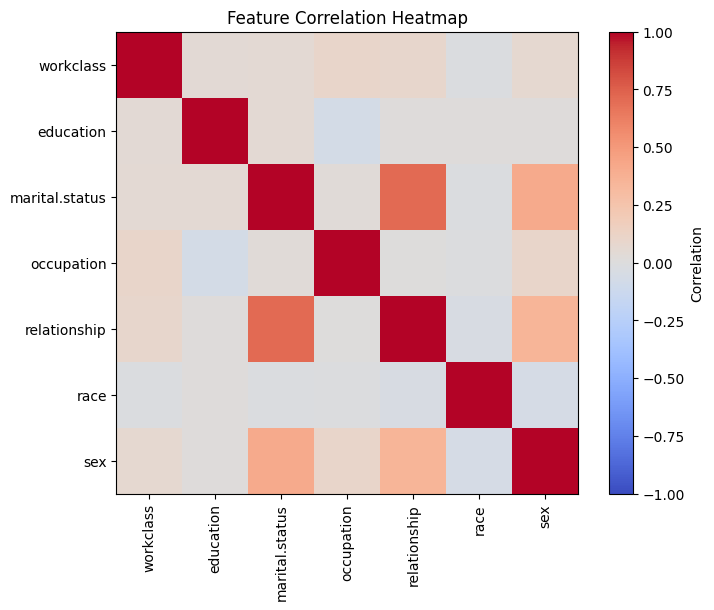

In [13]:
df_enc = pd.DataFrame(X_train, columns=categorical_features)
corr = df_enc.corr()
plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(categorical_features)), categorical_features, rotation=90)
plt.yticks(range(len(categorical_features)), categorical_features)
plt.title("Feature Correlation Heatmap")
plt.show()

- The Naive Bayes classifier assumes that all input features are conditionally independent given the class label.
- In this data set this isnt true:
For example the marital.status ↔ relationship are highly corelated which is 0.709 
- this heat map shows that there are several features that are somehow correlated.
- This makes the accuracy reasonably well while recall performs badly and this also explains why feature selection can significantly change model behavior.